In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [3]:
nav = pd.read_csv("../data/processed/02_nav_history.csv")

print(nav.shape)
nav.head()

(46000, 3)


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [4]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

In [5]:
nav.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB


In [6]:
nav.isnull().sum()

amfi_code    0
date         0
nav          0
dtype: int64

In [7]:
nav['amfi_code'].nunique()

40

In [8]:
nav['date'] = pd.to_datetime(nav['date'])

In [9]:
nav.dtypes

amfi_code             int64
date         datetime64[ns]
nav                 float64
dtype: object

In [10]:
nav = nav.sort_values(
    ['amfi_code','date']
)

nav.head()

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971
5752,100016,2022-01-05,521.7239
5753,100016,2022-01-06,515.7880
5754,100016,2022-01-07,515.1639


In [11]:
nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change()
)

In [12]:
nav.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [1]:
nav.to_csv(
    "../reports/returns_computed.csv",
    index=False
)

NameError: name 'nav' is not defined

In [2]:
import pandas as pd
import numpy as np

nav = pd.read_csv("../data/processed/02_nav_history.csv")

nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(['amfi_code','date'])

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change()
)

In [3]:
nav.to_csv(
    "../reports/returns_computed.csv",
    index=False
)

In [4]:
import os
os.listdir("../reports")

['aum_growth.png',
 'data_quality_summary.csv',
 'day1_summary.txt',
 'day2_summary.txt',
 'nav_trend.png',
 'returns_computed.csv']

In [5]:
import pandas as pd
import numpy as np

nav = pd.read_csv("../reports/returns_computed.csv")

nav['date'] = pd.to_datetime(nav['date'])

In [6]:
cagr_results = []

for fund in nav['amfi_code'].unique():

    fund_data = nav[nav['amfi_code'] == fund].sort_values('date')

    start_nav = fund_data['nav'].iloc[0]
    end_nav = fund_data['nav'].iloc[-1]

    years = (
        (fund_data['date'].iloc[-1] -
         fund_data['date'].iloc[0]).days
    ) / 365.25

    cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100

    cagr_results.append([
        fund,
        round(cagr, 2)
    ])

cagr_df = pd.DataFrame(
    cagr_results,
    columns=['amfi_code', 'cagr_percent']
)

cagr_df.head()

,amfi_code,cagr_percent
0,100016,2.64
1,100025,4.46
2,100033,30.12
3,101206,23.54
4,101207,7.94


In [7]:
cagr_df.to_csv(
    "../reports/cagr_report.csv",
    index=False
)

In [8]:
import os
os.listdir("../reports")

['aum_growth.png',
 'cagr_report.csv',
 'data_quality_summary.csv',
 'day1_summary.txt',
 'day2_summary.txt',
 'nav_trend.png',
 'returns_computed.csv']

In [9]:
risk_free_rate = 0.065   # 6.5%

sharpe_results = []

for fund in nav['amfi_code'].unique():

    fund_data = nav[nav['amfi_code'] == fund]

    mean_return = fund_data['daily_return'].mean() * 252

    volatility = (
        fund_data['daily_return'].std()
        * np.sqrt(252)
    )

    sharpe = (
        (mean_return - risk_free_rate)
        / volatility
    )

    sharpe_results.append([
        fund,
        round(sharpe, 2)
    ])

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        'amfi_code',
        'sharpe_ratio'
    ]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.20
1,100025,-0.57
2,100033,1.09
3,101206,1.03
4,101207,0.16


In [10]:
sharpe_df.to_csv(
    "../reports/sharpe_values.csv",
    index=False
)

In [11]:
sortino_results = []

for fund in nav['amfi_code'].unique():

    fund_data = nav[nav['amfi_code'] == fund]

    mean_return = fund_data['daily_return'].mean() * 252

    downside_returns = fund_data[
        fund_data['daily_return'] < 0
    ]['daily_return']

    downside_std = (
        downside_returns.std()
        * np.sqrt(252)
    )

    sortino = (
        (mean_return - risk_free_rate)
        / downside_std
    )

    sortino_results.append([
        fund,
        round(sortino, 2)
    ])

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        'amfi_code',
        'sortino_ratio'
    ]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.35
1,100025,-0.94
2,100033,1.83
3,101206,1.80
4,101207,0.28


In [12]:
sortino_df.to_csv(
    "../reports/sortino_values.csv",
    index=False
)

In [13]:
import os

os.listdir("../data/processed")

['01_fund_master.csv',
 '02_nav_history.csv',
 '03_aum_by_fund_house.csv',
 '04_monthly_sip_inflows.csv',
 '05_category_inflows.csv',
 '06_industry_folio_count.csv',
 '07_scheme_performance.csv',
 '08_investor_transactions.csv',
 '09_portfolio_holdings.csv',
 '10_benchmark_indices.csv',
 'axis_bluechip_nav.csv',
 'hdfc_top100_live_nav.csv',
 'hdfc_top100_nav.csv',
 'icici_bluechip_nav.csv',
 'kotak_bluechip_nav.csv',
 'nippon_largecap_nav.csv',
 'sbi_bluechip_nav.csv']

In [14]:
benchmark = pd.read_csv("../data/processed/10_benchmark_indices.csv")

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [15]:
benchmark.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         8050 non-null   object 
 1   index_name   8050 non-null   object 
 2   close_value  8050 non-null   float64
dtypes: float64(1), object(2)
memory usage: 188.8+ KB


In [16]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='object')

In [17]:
benchmark['date'] = pd.to_datetime(benchmark['date'])

nifty = benchmark[
    benchmark['index_name'] == 'NIFTY50'
].copy()

nifty = nifty.sort_values('date')

nifty['benchmark_return'] = (
    nifty['close_value']
    .pct_change()
)

nifty.head()

,date,index_name,close_value,benchmark_return
0,2022-01-03,NIFTY50,17492.79,NaN
1,2022-01-04,NIFTY50,17689.64,0.011253
2,2022-01-05,NIFTY50,17835.05,0.008220
3,2022-01-06,NIFTY50,17878.51,0.002437
4,2022-01-07,NIFTY50,17759.15,-0.006676


In [18]:
merged = pd.merge(
    nav,
    nifty[['date','benchmark_return']],
    on='date',
    how='inner'
)

merged.head()

,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,0.011253
2,100016,2022-01-05,521.7239,0.012865,0.008220
3,100016,2022-01-06,515.7880,-0.011377,0.002437
4,100016,2022-01-07,515.1639,-0.001210,-0.006676


In [19]:
from scipy.stats import linregress

In [20]:
alpha_beta_results = []

for fund in merged['amfi_code'].unique():

    temp = merged[
        merged['amfi_code'] == fund
    ].dropna()

    if len(temp) > 50:

        beta, alpha, r, p, std = linregress(
            temp['benchmark_return'],
            temp['daily_return']
        )

        alpha_beta_results.append([
            fund,
            round(alpha * 252, 4),
            round(beta, 4)
        ])

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        'amfi_code',
        'alpha',
        'beta'
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.0362,-0.0259
1,100025,0.0432,-0.0162
2,100033,0.2723,-0.0112
3,101206,0.2139,0.0338
4,101207,0.1082,-0.0599


In [21]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

alpha_beta_df.shape

(40, 3)

In [22]:
max_dd_results = []

for fund in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code'] == fund
    ].copy()

    temp = temp.sort_values('date')

    temp['running_max'] = temp['nav'].cummax()

    temp['drawdown'] = (
        temp['nav']
        /
        temp['running_max']
        - 1
    )

    max_dd = temp['drawdown'].min()

    max_dd_results.append([
        fund,
        round(max_dd * 100, 2)
    ])

max_dd_df = pd.DataFrame(
    max_dd_results,
    columns=[
        'amfi_code',
        'max_drawdown_percent'
    ]
)

max_dd_df.head()

,amfi_code,max_drawdown_percent
0,100016,-24.73
1,100025,-4.31
2,100033,-16.22
3,101206,-11.29
4,101207,-35.45


In [23]:
max_dd_df.to_csv(
    "../reports/max_drawdown.csv",
    index=False
)

max_dd_df.shape

(40, 2)

In [24]:
scorecard = cagr_df.merge(
    sharpe_df,
    on='amfi_code'
)

scorecard = scorecard.merge(
    sortino_df,
    on='amfi_code'
)

scorecard = scorecard.merge(
    alpha_beta_df[['amfi_code','alpha']],
    on='amfi_code'
)

scorecard = scorecard.merge(
    max_dd_df,
    on='amfi_code'
)

scorecard.head()

,amfi_code,cagr_percent,sharpe_ratio,sortino_ratio,alpha,max_drawdown_percent
0,100016,2.64,-0.20,-0.35,0.0362,-24.73
1,100025,4.46,-0.57,-0.94,0.0432,-4.31
2,100033,30.12,1.09,1.83,0.2723,-16.22
3,101206,23.54,1.03,1.80,0.2139,-11.29
4,101207,7.94,0.16,0.28,0.1082,-35.45


In [25]:
scorecard['cagr_rank'] = scorecard['cagr_percent'].rank(
    ascending=False
)

scorecard['sharpe_rank'] = scorecard['sharpe_ratio'].rank(
    ascending=False
)

scorecard['alpha_rank'] = scorecard['alpha'].rank(
    ascending=False
)

scorecard['drawdown_rank'] = scorecard[
    'max_drawdown_percent'
].rank(
    ascending=False
)

scorecard.head()

,amfi_code,cagr_percent,sharpe_ratio,sortino_ratio,alpha,max_drawdown_percent,cagr_rank,sharpe_rank,alpha_rank,drawdown_rank
0,100016,2.64,-0.20,-0.35,0.0362,-24.73,37.0,35.0,39.0,34.0
1,100025,4.46,-0.57,-0.94,0.0432,-4.31,36.0,39.0,38.0,4.0
2,100033,30.12,1.09,1.83,0.2723,-16.22,7.0,7.0,6.0,20.0
3,101206,23.54,1.03,1.80,0.2139,-11.29,12.0,9.5,12.0,9.0
4,101207,7.94,0.16,0.28,0.1082,-35.45,27.0,28.0,27.0,38.0


In [26]:
scorecard['final_score'] = (
    0.30 * scorecard['cagr_rank']
    +
    0.25 * scorecard['sharpe_rank']
    +
    0.20 * scorecard['alpha_rank']
    +
    0.10 * scorecard['drawdown_rank']
)

scorecard = scorecard.sort_values(
    'final_score'
)

scorecard.head(10)

,amfi_code,cagr_percent,sharpe_ratio,sortino_ratio,alpha,max_drawdown_percent,cagr_rank,sharpe_rank,alpha_rank,drawdown_rank,final_score
34,148567,30.97,1.45,2.39,0.2712,-11.27,5.0,1.0,7.0,8.0,3.950
30,120843,30.91,1.31,2.36,0.2728,-12.97,6.0,2.0,5.0,13.0,4.600
25,120505,32.83,1.18,2.03,0.2930,-18.19,1.0,5.0,3.0,25.0,4.650
36,148569,31.95,1.23,2.15,0.2835,-16.40,4.0,3.0,4.0,21.0,4.850
2,100033,30.12,1.09,1.83,0.2723,-16.22,7.0,7.0,6.0,20.0,7.050
21,119598,32.42,0.95,1.68,0.3011,-28.71,2.0,13.0,1.0,36.0,7.650
19,119551,25.80,1.21,2.14,0.2322,-15.01,10.0,4.0,10.0,17.0,7.700
38,149323,29.58,1.13,1.88,0.2658,-17.25,8.0,6.0,8.0,22.0,7.700
39,149324,32.29,0.95,1.62,0.2982,-31.17,3.0,13.0,2.0,37.0,8.250
3,101206,23.54,1.03,1.80,0.2139,-11.29,12.0,9.5,12.0,9.0,9.275


In [27]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

scorecard.shape

(40, 11)

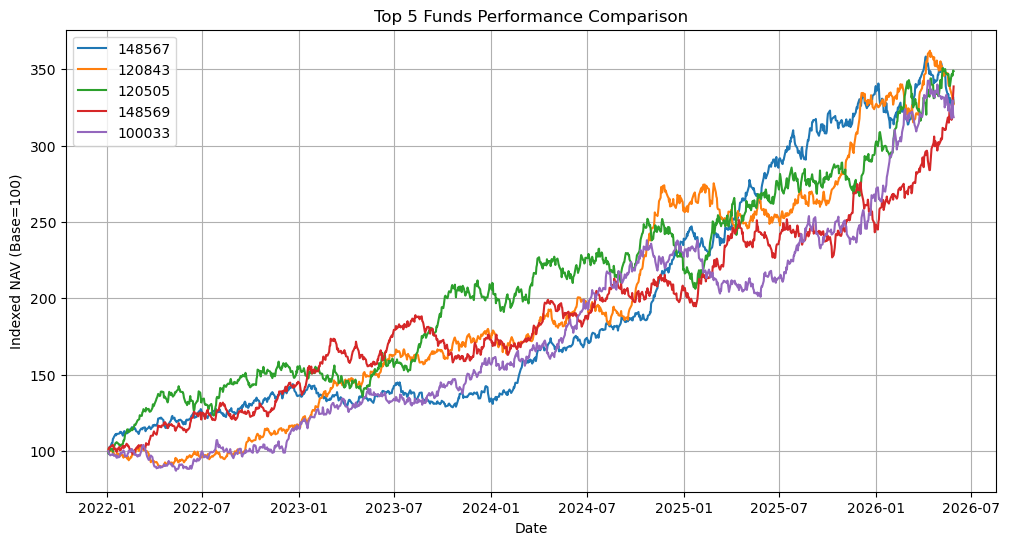

In [28]:
import matplotlib.pyplot as plt

top5 = scorecard.head(5)['amfi_code'].tolist()

plt.figure(figsize=(12,6))

for fund in top5:

    temp = nav[
        nav['amfi_code'] == fund
    ].copy()

    temp = temp.sort_values('date')

    normalized = (
        temp['nav']
        /
        temp['nav'].iloc[0]
    ) * 100

    plt.plot(
        temp['date'],
        normalized,
        label=str(fund)
    )

plt.title('Top 5 Funds Performance Comparison')
plt.xlabel('Date')
plt.ylabel('Indexed NAV (Base=100)')
plt.legend()
plt.grid(True)

plt.show()

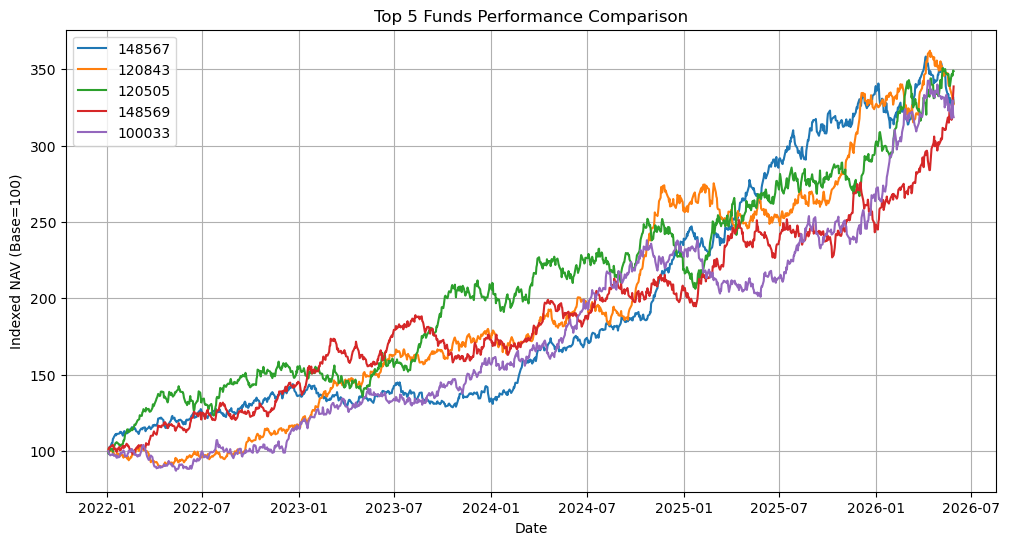

In [29]:
plt.figure(figsize=(12,6))

for fund in top5:

    temp = nav[
        nav['amfi_code'] == fund
    ].copy()

    temp = temp.sort_values('date')

    normalized = (
        temp['nav']
        /
        temp['nav'].iloc[0]
    ) * 100

    plt.plot(
        temp['date'],
        normalized,
        label=str(fund)
    )

plt.title('Top 5 Funds Performance Comparison')
plt.xlabel('Date')
plt.ylabel('Indexed NAV (Base=100)')
plt.legend()
plt.grid(True)

plt.savefig(
    "../reports/benchmark_chart.png",
    bbox_inches="tight"
)

plt.show()

## Day 4 - Fund Performance Analytics ✅

Completed:

- Daily Return Calculation
- CAGR Analysis
- Sharpe Ratio Computation
- Sortino Ratio Computation
- Alpha & Beta Calculation
- Maximum Drawdown Analysis
- Fund Scorecard Generation
- Top 5 Funds Benchmark Comparison Chart

Generated Files:

- returns_computed.csv
- cagr_report.csv
- sharpe_values.csv
- sortino_values.csv
- alpha_beta.csv
- max_drawdown.csv
- fund_scorecard.csv
- benchmark_chart.png

In [30]:
scheme = pd.read_csv("../data/processed/07_scheme_performance.csv")

scheme.columns


Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

In [31]:
scheme = pd.read_csv("../data/processed/07_scheme_performance.csv")

expense_df = scheme[['amfi_code', 'expense_ratio_pct']]

scorecard = scorecard.merge(
    expense_df,
    on='amfi_code',
    how='left'
)

In [33]:
scorecard['expense_rank'] = scorecard[
    'expense_ratio_pct'
].rank(
    ascending=True
)

In [34]:
scorecard['final_score'] = (
    0.30 * scorecard['cagr_rank']
    + 0.25 * scorecard['sharpe_rank']
    + 0.20 * scorecard['alpha_rank']
    + 0.15 * scorecard['expense_rank']
    + 0.10 * scorecard['dd_rank']
)

KeyError: 'dd_rank'

In [35]:
scorecard.columns

Index(['amfi_code', 'cagr_percent', 'sharpe_ratio', 'sortino_ratio', 'alpha',
       'max_drawdown_percent', 'cagr_rank', 'sharpe_rank', 'alpha_rank',
       'drawdown_rank', 'final_score', 'expense_ratio_pct', 'expense_rank'],
      dtype='object')

In [36]:
scorecard['final_score'] = (
    0.30 * scorecard['cagr_rank']
    + 0.25 * scorecard['sharpe_rank']
    + 0.20 * scorecard['alpha_rank']
    + 0.15 * scorecard['expense_rank']
    + 0.10 * scorecard['drawdown_rank']
)

In [37]:
scorecard = scorecard.sort_values(
    'final_score',
    ascending=False
)

scorecard.head()

,amfi_code,cagr_percent,sharpe_ratio,sortino_ratio,alpha,max_drawdown_percent,cagr_rank,sharpe_rank,alpha_rank,drawdown_rank,final_score,expense_ratio_pct,expense_rank
39,102886,1.17,-0.21,-0.35,0.0289,-28.00,40.0,36.0,40.0,35.0,36.175,1.51,24.5
37,100016,2.64,-0.20,-0.35,0.0362,-24.73,37.0,35.0,39.0,34.0,35.850,1.55,32.0
38,119095,1.52,-0.08,-0.13,0.0457,-51.68,39.0,33.0,37.0,39.0,33.800,1.38,17.0
36,119599,2.05,-0.06,-0.09,0.0506,-52.57,38.0,32.0,36.0,40.0,31.425,0.72,5.5
30,119092,6.37,0.03,0.05,0.0697,-14.40,33.0,31.0,30.0,15.0,31.075,1.64,39.5


In [38]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

In [39]:
import os
os.listdir("../reports")

['alpha_beta.csv',
 'aum_growth.png',
 'benchmark_chart.png',
 'cagr_report.csv',
 'data_quality_summary.csv',
 'day1_summary.txt',
 'day2_summary.txt',
 'fund_scorecard.csv',
 'max_drawdown.csv',
 'nav_trend.png',
 'returns_computed.csv',
 'sharpe_values.csv',
 'sortino_values.csv']